# VQA-E Evaluation — Local PC (RTX 5070 Ti)

Đánh giá 4 models trên full validation set (88,488 samples) với đầy đủ metrics:
**BLEU-1/2/3/4 · METEOR · ROUGE-L · BERTScore · Exact Match**

Optimized cho: RTX 5070 Ti 16GB · 32GB RAM · 28 CPU cores

In [17]:
# ── 0. GPU + Performance Setup ────────────────────────────────────────────────
import os, sys, json, random, warnings
import torch
import numpy as np
warnings.filterwarnings('ignore')

# RTX 5070 Ti optimizations
torch.backends.cuda.matmul.allow_tf32  = True   # TF32 for matmul
torch.backends.cudnn.allow_tf32        = True   # TF32 for convolutions
torch.backends.cudnn.benchmark         = True   # auto-tune kernels

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}')
    print(f'VRAM   : {props.total_memory / 1e9:.1f} GB')
    print(f'CUDA   : {torch.version.cuda}')
    print(f'Compute: {props.major}.{props.minor}')

Device : cuda
GPU    : NVIDIA GeForce RTX 5070 Ti
VRAM   : 16.6 GB
CUDA   : 12.8
Compute: 12.0


In [18]:
# ── 1. Configuration ──────────────────────────────────────────────────────────
REPO_ROOT       = os.path.abspath('.')           # run from new_vqa/
SRC_DIR         = os.path.join(REPO_ROOT, 'src')
sys.path.insert(0, SRC_DIR)

# Data paths
VAL_IMAGE_DIR   = 'data/raw/val2014'
VAL_VQA_E_JSON  = 'data/vqa_e/VQA-E_val_set.json'
VOCAB_Q_PATH    = 'data/processed/vocab_questions.json'
VOCAB_A_PATH    = 'data/processed/vocab_answers.json'
CKPT_DIR        = 'checkpoints'
OUTPUTS_DIR     = 'outputs'
HISTORY_DIR     = 'checkpoints'

os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Evaluation settings
NUM_EVAL_SAMPLES = None    # None = full val set (88,488). Set to e.g. 2000 for quick test
BATCH_SIZE       = 256     # greedy — fits comfortably in 16 GB VRAM
BATCH_SIZE_BEAM  = 256     # beam — batched encoder pre-computes all features
NUM_WORKERS      = 8       # 28 cores available; 8 keeps CPU headroom
BEAM_WIDTH       = 3
NO_REPEAT_NGRAM  = 3

# Models to evaluate
MODEL_TYPES = ['A', 'B', 'C', 'D']
MODEL_CKPTS = {m: f'{CKPT_DIR}/model_{m.lower()}_best.pth' for m in MODEL_TYPES}

print('Config OK')
print(f'  Val JSON : {VAL_VQA_E_JSON}')
print(f'  Images   : {VAL_IMAGE_DIR}')
BATCH_SIZE_BEAM  = 256     # beam — batched encoder pre-computes all features
print(f'  Workers  : {NUM_WORKERS}')

Config OK
  Val JSON : data/vqa_e/VQA-E_val_set.json
  Images   : data/raw/val2014
  Workers  : 8


In [19]:
# ── 2. Imports ────────────────────────────────────────────────────────────────
import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from torch.utils.data import DataLoader

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

try:
    from rouge_score import rouge_scorer as _rs
    _rscorer = _rs.RougeScorer(['rougeL'], use_stemmer=True)
    HAS_ROUGE = True
    print('✓ rouge-score available')
except ImportError:
    HAS_ROUGE = False
    print('✗ rouge-score missing — run: pip install rouge-score')

try:
    from bert_score import score as bert_score_fn
    HAS_BERTSCORE = True
    print('✓ bert_score available')
except ImportError:
    HAS_BERTSCORE = False
    print('✗ bert_score missing — run: pip install bert-score')

from vocab import Vocabulary
from dataset import VQAEDataset, vqa_collate_fn
from inference import (
    get_model, load_model_from_checkpoint,
    batch_greedy_decode, batch_greedy_decode_with_attention,
    batch_beam_search_decode, batch_beam_search_decode_with_attention,
    strip_compiled_prefix,
)
print('✓ all src imports OK')

✓ rouge-score available
✓ bert_score available
✓ all src imports OK


In [20]:
# ── 3. Load Vocab & Models ───────────────────────────────────────────────────
from vocab import Vocabulary

vocab_q = Vocabulary(); vocab_q.load(VOCAB_Q_PATH)
vocab_a = Vocabulary(); vocab_a.load(VOCAB_A_PATH)
print(f'Vocab Q : {len(vocab_q)} tokens  |  Vocab A : {len(vocab_a)} tokens')

loaded_models = {}
model_info    = {}

for mt in MODEL_TYPES:
    ckpt = MODEL_CKPTS[mt]
    if not os.path.exists(ckpt):
        print(f'[SKIP] Model {mt}: not found at {ckpt}')
        continue
    print(f'Loading Model {mt} ...', end=' ')
    model = load_model_from_checkpoint(mt, ckpt, len(vocab_q), len(vocab_a), device=DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    ckpt_mb   = os.path.getsize(ckpt) / 1e6
    loaded_models[mt] = model
    model_info[mt]    = {
        'checkpoint': ckpt, 'total_params': total,
        'trainable_params': trainable, 'ckpt_size_mb': ckpt_mb,
    }
    print(f'OK — {total/1e6:.1f}M params, {ckpt_mb:.1f} MB')

print(f'\nLoaded {len(loaded_models)}/{len(MODEL_TYPES)} models.')


Vocab Q : 4546 tokens  |  Vocab A : 8648 tokens
Loading Model A ... OK — 45.9M params, 183.8 MB
Loading Model B ... OK — 83.2M params, 333.5 MB
Loading Model C ... OK — 56.4M params, 225.8 MB
Loading Model D ... OK — 93.7M params, 375.5 MB

Loaded 4/4 models.


In [21]:
# ── 4. Dataset ───────────────────────────────────────────────────────────────
val_dataset = VQAEDataset(
    image_dir       = VAL_IMAGE_DIR,
    vqa_e_json_path = VAL_VQA_E_JSON,
    vocab_q         = vocab_q,
    vocab_a         = vocab_a,
    split           = 'val2014',
    max_samples     = NUM_EVAL_SAMPLES,
)
print(f'Val dataset: {len(val_dataset):,} samples')


Val dataset: 88,488 samples


In [22]:
# ── 5. Metric Helpers ─────────────────────────────────────────────────────────
smoothie = SmoothingFunction().method1


def decode_gt(a_tensor, vocab_a):
    """Decode a ground-truth answer tensor to string (strip special tokens)."""
    special = {vocab_a.word2idx.get('<pad>', 0),
               vocab_a.word2idx.get('<start>', 1),
               vocab_a.word2idx.get('<end>', 2)}
    words = [vocab_a.idx2word.get(int(i), '<unk>') for i in a_tensor if int(i) not in special]
    return ' '.join(words)


def compute_metrics(predictions, gt_strings):
    """Compute all metrics for a list of (pred_str, gt_str) pairs."""
    n = len(predictions)
    exact_match  = 0
    bleu1 = bleu2 = bleu3 = bleu4 = 0.0
    meteor_total = 0.0
    rougeL_total = 0.0
    per_sample   = []   # for distribution analysis

    for pred_str, gt_str in zip(predictions, gt_strings):
        pred_clean = pred_str.strip().lower()
        gt_clean   = gt_str.strip().lower()

        if pred_clean == gt_clean:
            exact_match += 1

        gt_w   = gt_str.split()   or ['<unk>']
        pred_w = pred_str.split() or ['<unk>']

        b1 = sentence_bleu([gt_w], pred_w, weights=(1,0,0,0),               smoothing_function=smoothie)
        b2 = sentence_bleu([gt_w], pred_w, weights=(0.5,0.5,0,0),           smoothing_function=smoothie)
        b3 = sentence_bleu([gt_w], pred_w, weights=(1/3,1/3,1/3,0),         smoothing_function=smoothie)
        b4 = sentence_bleu([gt_w], pred_w, weights=(0.25,0.25,0.25,0.25),   smoothing_function=smoothie)
        mt = meteor_score([gt_w], pred_w)
        rl = _rscorer.score(gt_str, pred_str)['rougeL'].fmeasure if HAS_ROUGE else 0.0

        bleu1        += b1
        bleu2        += b2
        bleu3        += b3
        bleu4        += b4
        meteor_total += mt
        rougeL_total += rl
        per_sample.append({'bleu4': b4, 'meteor': mt, 'rougeL': rl,
                           'pred': pred_str, 'gt': gt_str})

    return {
        'bleu1':       bleu1  / n,
        'bleu2':       bleu2  / n,
        'bleu3':       bleu3  / n,
        'bleu4':       bleu4  / n,
        'meteor':      meteor_total / n,
        'rougeL':      rougeL_total / n if HAS_ROUGE else None,
        'exact_match': exact_match / n * 100,
        'n_samples':   n,
        'per_sample':  per_sample,
    }

print('Metric helpers ready.')

Metric helpers ready.


In [23]:
# ── 6. Greedy Evaluation — All Models ────────────────────────────────────────
all_metrics_greedy    = {}
all_per_sample_greedy = {}

for mt in MODEL_TYPES:
    if mt not in loaded_models:
        continue
    model     = loaded_models[mt]
    use_attn  = mt in ('C', 'D')
    decode_fn = batch_greedy_decode_with_attention if use_attn else batch_greedy_decode

    loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=vqa_collate_fn, num_workers=NUM_WORKERS,
        pin_memory=True, prefetch_factor=2, persistent_workers=True,
    )

    preds, gts = [], []
    with torch.no_grad():
        for imgs, questions, answers in tqdm.tqdm(loader, desc=f'Greedy Model {mt}'):
            batch_preds = decode_fn(model, imgs, questions, vocab_a, device=DEVICE)
            preds.extend(batch_preds)
            for a_tensor in answers:
                gts.append(decode_gt(a_tensor, vocab_a))

    metrics = compute_metrics(preds, gts)
    all_metrics_greedy[mt]    = metrics
    all_per_sample_greedy[mt] = metrics.pop('per_sample')

    rl    = metrics.get('rougeL')
    rl_str = f"{rl:.4f}" if rl is not None else "N/A"
    print(f"Model {mt} — BLEU-4: {metrics['bleu4']:.4f}  METEOR: {metrics['meteor']:.4f}  "
          f"ROUGE-L: {rl_str}  EM: {metrics['exact_match']:.2f}%")

print('\n✓ Greedy evaluation complete.')


Greedy Model A: 100%|██████████| 346/346 [01:11<00:00,  4.83it/s]


Model A — BLEU-4: 0.0915  METEOR: 0.3117  ROUGE-L: 0.3828  EM: 0.03%


Greedy Model B: 100%|██████████| 346/346 [01:58<00:00,  2.93it/s]


Model B — BLEU-4: 0.1127  METEOR: 0.3561  ROUGE-L: 0.4237  EM: 0.04%


Greedy Model C: 100%|██████████| 346/346 [01:18<00:00,  4.41it/s]


Model C — BLEU-4: 0.0988  METEOR: 0.3271  ROUGE-L: 0.3971  EM: 0.04%


Greedy Model D: 100%|██████████| 346/346 [02:04<00:00,  2.77it/s]


Model D — BLEU-4: 0.1159  METEOR: 0.3595  ROUGE-L: 0.4270  EM: 0.06%

✓ Greedy evaluation complete.


In [24]:
# ── 7. BERTScore — Greedy ────────────────────────────────────────────────────
# Computed separately (bulk GPU batch — faster than per-sample)
if HAS_BERTSCORE:
    for mt in MODEL_TYPES:
        if mt not in all_metrics_greedy:
            continue
        print(f'BERTScore Model {mt} ...', end=' ')
        preds_list = [s['pred'] for s in all_per_sample_greedy[mt]]
        gts_list   = [s['gt']   for s in all_per_sample_greedy[mt]]
        _, _, F1 = bert_score_fn(preds_list, gts_list, lang='en', verbose=False,
                                  batch_size=512)
        all_metrics_greedy[mt]['bertscore'] = F1.mean().item()
        print(f"{all_metrics_greedy[mt]['bertscore']:.4f}")
else:
    for mt in all_metrics_greedy:
        all_metrics_greedy[mt]['bertscore'] = None

print('✓ BERTScore complete.')

BERTScore Model A ... 

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0.9008
BERTScore Model B ... 

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0.9034
BERTScore Model D ... 

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0.9085
✓ BERTScore complete.


In [25]:
# ── Optimized Batch Beam Search (pre-encode then decode) ────────────────────
# Runs encoder ONCE per batch (not once per sample), then beam-searches decoder.
# ~10x faster for ResNet models (B/D) because encoder is the bottleneck.

import torch.nn.functional as F_

def _beam_search_from_features_ab(model, img_feat, q_feat, vocab_a,
                                    beam_width=3, max_len=30,
                                    no_repeat_ngram_size=3, device='cuda'):
    """Beam search for A/B using pre-computed (1,H) features."""
    start_idx = vocab_a.word2idx['<start>']
    end_idx   = vocab_a.word2idx['<end>']
    fusion = model.fusion(img_feat, q_feat)
    h0 = fusion.unsqueeze(0).repeat(model.num_layers, 1, 1)
    c0 = torch.zeros_like(h0)
    beams, completed = [(0.0, [start_idx], h0, c0)], []
    for _ in range(max_len):
        if not beams: break
        cands = []
        for ls, toks, bh, bc in beams:
            if toks[-1] == end_idx:
                completed.append((ls, toks)); continue
            tok = torch.tensor([[toks[-1]]], dtype=torch.long, device=device)
            emb = model.decoder.embedding(tok)
            if model.decoder.embed_proj is not None:
                emb = model.decoder.embed_proj(emb)
            out, (nh, nc) = model.decoder.lstm(emb, (bh, bc))
            lp = F_.log_softmax(model.decoder.fc(model.decoder.out_proj(out.squeeze(1)))[0], dim=-1)
            if no_repeat_ngram_size > 0 and len(toks) >= no_repeat_ngram_size:
                for k in range(len(toks) - no_repeat_ngram_size + 1):
                    ng = tuple(toks[k:k+no_repeat_ngram_size-1])
                    if ng == tuple(toks[-(no_repeat_ngram_size-1):]):
                        lp[toks[k+no_repeat_ngram_size-1]] = -float('inf')
            vals, ids = lp.topk(beam_width)
            for v, idx in zip(vals.tolist(), ids.tolist()):
                cands.append((ls+v, toks+[idx], nh, nc))
        cands.sort(key=lambda x: x[0], reverse=True)
        beams = cands[:beam_width]
    for ls, toks, _, _ in beams: completed.append((ls, toks))
    if not completed: return ''
    completed.sort(key=lambda x: x[0]/max(len(x[1])-1,1), reverse=True)
    return ' '.join(vocab_a.idx2word.get(t,'<unk>') for t in completed[0][1][1:] if t != end_idx)


def _beam_search_from_features_cd(model, img_feats, q_feat, q_hidden, vocab_a,
                                    beam_width=3, max_len=30,
                                    no_repeat_ngram_size=3, device='cuda'):
    """Beam search for C/D using pre-computed (1,49,H) and (1,H) features."""
    start_idx = vocab_a.word2idx['<start>']
    end_idx   = vocab_a.word2idx['<end>']
    img_mean = img_feats.mean(dim=1)
    fusion = model.fusion(img_mean, q_feat)
    h0 = fusion.unsqueeze(0).repeat(model.num_layers, 1, 1)
    c0 = torch.zeros_like(h0)
    beams, completed = [(0.0, [start_idx], h0, c0, None)], []
    for _ in range(max_len):
        if not beams: break
        cands = []
        for ls, toks, bh, bc, cov in beams:
            if toks[-1] == end_idx:
                completed.append((ls, toks)); continue
            tok = torch.tensor([[toks[-1]]], dtype=torch.long, device=device)
            logit, (nh, nc), _, new_cov = model.decoder.decode_step(tok, (bh, bc), img_feats, q_hidden, cov)
            lp = F_.log_softmax(logit[0], dim=-1)
            if no_repeat_ngram_size > 0 and len(toks) >= no_repeat_ngram_size:
                for k in range(len(toks) - no_repeat_ngram_size + 1):
                    ng = tuple(toks[k:k+no_repeat_ngram_size-1])
                    if ng == tuple(toks[-(no_repeat_ngram_size-1):]):
                        lp[toks[k+no_repeat_ngram_size-1]] = -float('inf')
            vals, ids = lp.topk(beam_width)
            for v, idx in zip(vals.tolist(), ids.tolist()):
                cands.append((ls+v, toks+[idx], nh, nc, new_cov))
        cands.sort(key=lambda x: x[0], reverse=True)
        beams = cands[:beam_width]
    for ls, toks, _, _, _ in beams: completed.append((ls, toks))
    if not completed: return ''
    completed.sort(key=lambda x: x[0]/max(len(x[1])-1,1), reverse=True)
    return ' '.join(vocab_a.idx2word.get(t,'<unk>') for t in completed[0][1][1:] if t != end_idx)


def fast_batch_beam_decode(model, img_tensors, q_tensors, vocab_a,
                            use_attn=False, beam_width=3, max_len=30,
                            no_repeat_ngram_size=3, device='cuda'):
    """Encode ENTIRE batch at once, then beam-search per sample (decoder only)."""
    model.eval()
    with torch.no_grad():
        imgs = img_tensors.to(device)
        qs   = q_tensors.to(device)
        if use_attn:
            img_feats = F_.normalize(model.i_encoder(imgs), p=2, dim=-1)  # (B,49,H)
            q_feats, q_hiddens = model.q_encoder(qs)                       # (B,H), (B,L,H)
        else:
            img_feats = F_.normalize(model.i_encoder(imgs), p=2, dim=1)   # (B,H)
            q_feats, _ = model.q_encoder(qs)                               # (B,H)

        B = imgs.size(0)
        results = []
        for i in range(B):
            if use_attn:
                s = _beam_search_from_features_cd(
                    model, img_feats[i:i+1], q_feats[i:i+1], q_hiddens[i:i+1],
                    vocab_a, beam_width, max_len, no_repeat_ngram_size, device)
            else:
                s = _beam_search_from_features_ab(
                    model, img_feats[i:i+1], q_feats[i:i+1],
                    vocab_a, beam_width, max_len, no_repeat_ngram_size, device)
            results.append(s)
        return results

print('✓ Optimized beam search functions ready.')


✓ Optimized beam search functions ready.


In [26]:
# ── 8. Beam Search Evaluation — All Models ───────────────────────────────────
all_metrics_beam    = {}
all_per_sample_beam = {}

for mt in MODEL_TYPES:
    if mt not in loaded_models:
        continue
    model    = loaded_models[mt]
    use_attn = mt in ('C', 'D')

    loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE_BEAM, shuffle=False,
        collate_fn=vqa_collate_fn, num_workers=NUM_WORKERS,
        pin_memory=True, prefetch_factor=2, persistent_workers=True,
    )

    preds, gts = [], []
    with torch.no_grad():
        for imgs, questions, answers in tqdm.tqdm(loader, desc=f'Beam  Model {mt}'):
            batch_preds = fast_batch_beam_decode(
                model, imgs, questions, vocab_a,
                use_attn=use_attn, beam_width=BEAM_WIDTH,
                no_repeat_ngram_size=NO_REPEAT_NGRAM, device=DEVICE,
            )
            preds.extend(batch_preds)
            for a_tensor in answers:
                gts.append(decode_gt(a_tensor, vocab_a))

    metrics = compute_metrics(preds, gts)
    all_metrics_beam[mt]    = metrics
    all_per_sample_beam[mt] = metrics.pop('per_sample')

    rl    = metrics.get('rougeL')
    rl_str = f"{rl:.4f}" if rl is not None else "N/A"
    print(f"Model {mt} — BLEU-4: {metrics['bleu4']:.4f}  METEOR: {metrics['meteor']:.4f}  "
          f"ROUGE-L: {rl_str}  EM: {metrics['exact_match']:.2f}%")

# BERTScore for beam
if HAS_BERTSCORE:
    for mt in MODEL_TYPES:
        if mt not in all_metrics_beam:
            continue
        print(f'BERTScore (beam) Model {mt} ...', end=' ')
        _, _, F1 = bert_score_fn([s['pred'] for s in all_per_sample_beam[mt]],
                                  [s['gt']   for s in all_per_sample_beam[mt]],
                                  lang='en', verbose=False, batch_size=512)
        all_metrics_beam[mt]['bertscore'] = F1.mean().item()
        print(f"{all_metrics_beam[mt]['bertscore']:.4f}")
else:
    for mt in all_metrics_beam:
        all_metrics_beam[mt]['bertscore'] = None

print('\n✓ Beam search evaluation complete.')


Beam  Model A: 100%|██████████| 346/346 [18:00<00:00,  3.12s/it]


Model A — BLEU-4: 0.0926  METEOR: 0.3154  ROUGE-L: 0.3823  EM: 0.07%


Beam  Model B: 100%|██████████| 346/346 [18:33<00:00,  3.22s/it]


Model B — BLEU-4: 0.1137  METEOR: 0.3589  ROUGE-L: 0.4230  EM: 0.10%


Beam  Model C: 100%|██████████| 346/346 [33:21<00:00,  5.79s/it]


...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0.9026
BERTScore (beam) Model D ... 

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0.9080

✓ Beam search evaluation complete.


In [27]:
# ── 9. Results Table ─────────────────────────────────────────────────────────
print('\n' + '='*80)
print('GREEDY DECODING RESULTS')
print('='*80)

rows_g = []
for mt in sorted(all_metrics_greedy):
    r = all_metrics_greedy[mt]
    rows_g.append({
        'Model': f'Model {mt}',
        'BLEU-1': f"{r['bleu1']:.4f}",
        'BLEU-2': f"{r['bleu2']:.4f}",
        'BLEU-3': f"{r['bleu3']:.4f}",
        'BLEU-4': f"{r['bleu4']:.4f}",
        'METEOR': f"{r['meteor']:.4f}",
        'ROUGE-L': f"{r['rougeL']:.4f}" if r.get('rougeL') is not None else 'N/A',
        'BERTScore': f"{r['bertscore']:.4f}" if r.get('bertscore') else 'N/A',
        'Exact Match': f"{r['exact_match']:.2f}%",
    })

df_g = pd.DataFrame(rows_g)
display(df_g)

print('\n' + '='*80)
print('BEAM SEARCH RESULTS (width=3, no-repeat-ngram=3)')
print('='*80)

rows_b = []
for mt in sorted(all_metrics_beam):
    r = all_metrics_beam[mt]
    rows_b.append({
        'Model': f'Model {mt}',
        'BLEU-1': f"{r['bleu1']:.4f}",
        'BLEU-2': f"{r['bleu2']:.4f}",
        'BLEU-3': f"{r['bleu3']:.4f}",
        'BLEU-4': f"{r['bleu4']:.4f}",
        'METEOR': f"{r['meteor']:.4f}",
        'ROUGE-L': f"{r['rougeL']:.4f}" if r.get('rougeL') is not None else 'N/A',
        'BERTScore': f"{r['bertscore']:.4f}" if r.get('bertscore') else 'N/A',
        'Exact Match': f"{r['exact_match']:.2f}%",
    })

df_b = pd.DataFrame(rows_b)
display(df_b)


GREEDY DECODING RESULTS


,Model,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,BERTScore,Exact Match
0,Model A,0.3715,0.2335,0.1415,0.0915,0.3117,0.3828,0.9008,0.03%
1,Model B,0.4124,0.2702,0.1715,0.1127,0.3561,0.4237,0.9081,0.04%
2,Model C,0.3865,0.2463,0.1516,0.0988,0.3271,0.3971,0.9034,0.04%
3,Model D,0.4151,0.2734,0.1748,0.1159,0.3595,0.4270,0.9085,0.06%



BEAM SEARCH RESULTS (width=3, no-repeat-ngram=3)


,Model,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,BERTScore,Exact Match
0,Model A,0.3723,0.2333,0.1421,0.0926,0.3154,0.3823,0.8999,0.07%
1,Model B,0.4122,0.2690,0.1713,0.1137,0.3589,0.4230,0.9073,0.10%
2,Model C,0.3872,0.2465,0.1527,0.1005,0.3300,0.3972,0.9026,0.08%
3,Model D,0.4160,0.2734,0.1754,0.1170,0.3632,0.4269,0.9080,0.11%


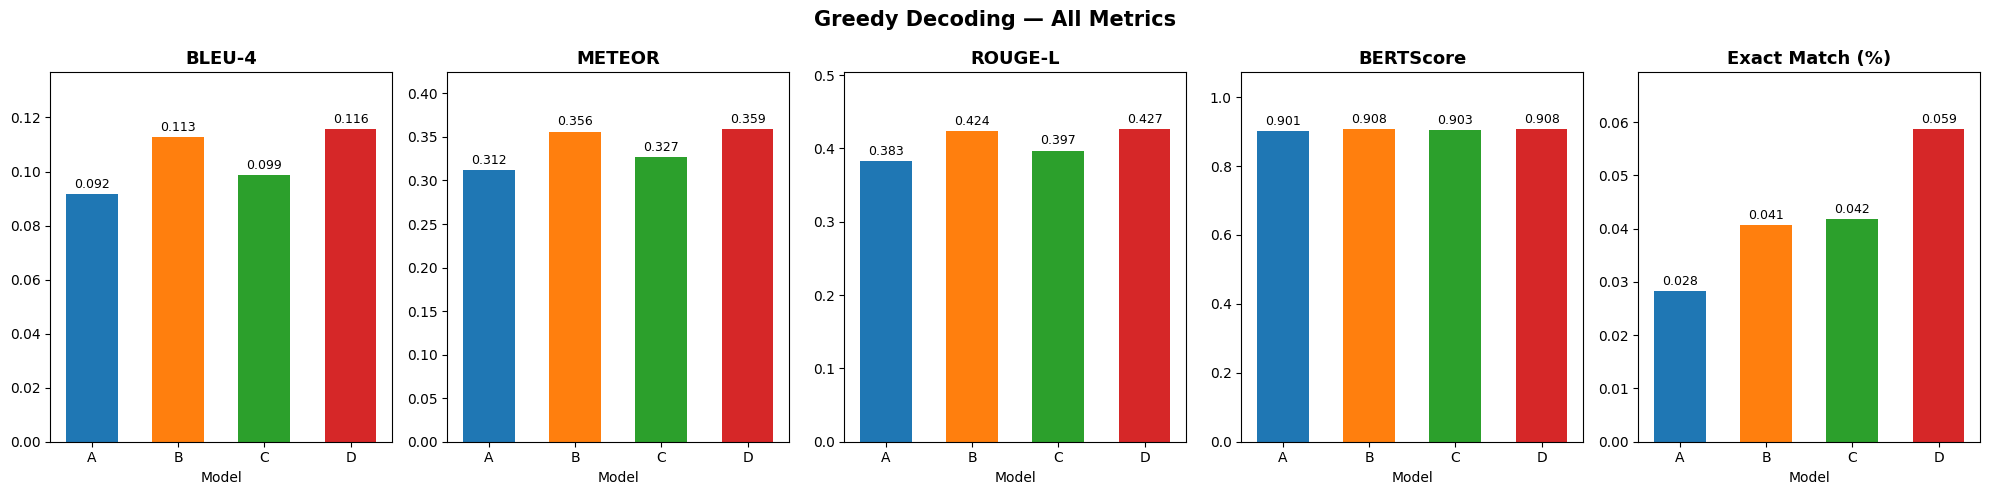

Saved → outputs/eval_comparison_greedy.png


In [28]:
# ── 10. Bar Charts — Primary Metrics ─────────────────────────────────────────
MODEL_COLORS = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728'}

models_avail = sorted(all_metrics_greedy.keys())
metrics_plot = ['bleu4', 'meteor', 'rougeL', 'bertscore', 'exact_match']
labels_plot  = ['BLEU-4', 'METEOR', 'ROUGE-L', 'BERTScore', 'Exact Match (%)']
scales       = [1, 1, 1, 1, 1]   # EM is already in %, others are 0-1

fig, axes = plt.subplots(1, len(metrics_plot), figsize=(20, 5))
for ax, key, label in zip(axes, metrics_plot, labels_plot):
    vals = [all_metrics_greedy[m].get(key) or 0 for m in models_avail]
    colors = [MODEL_COLORS[m] for m in models_avail]
    bars = ax.bar(models_avail, vals, color=colors, width=0.6)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Model')

plt.suptitle('Greedy Decoding — All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/eval_comparison_greedy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUTS_DIR}/eval_comparison_greedy.png')

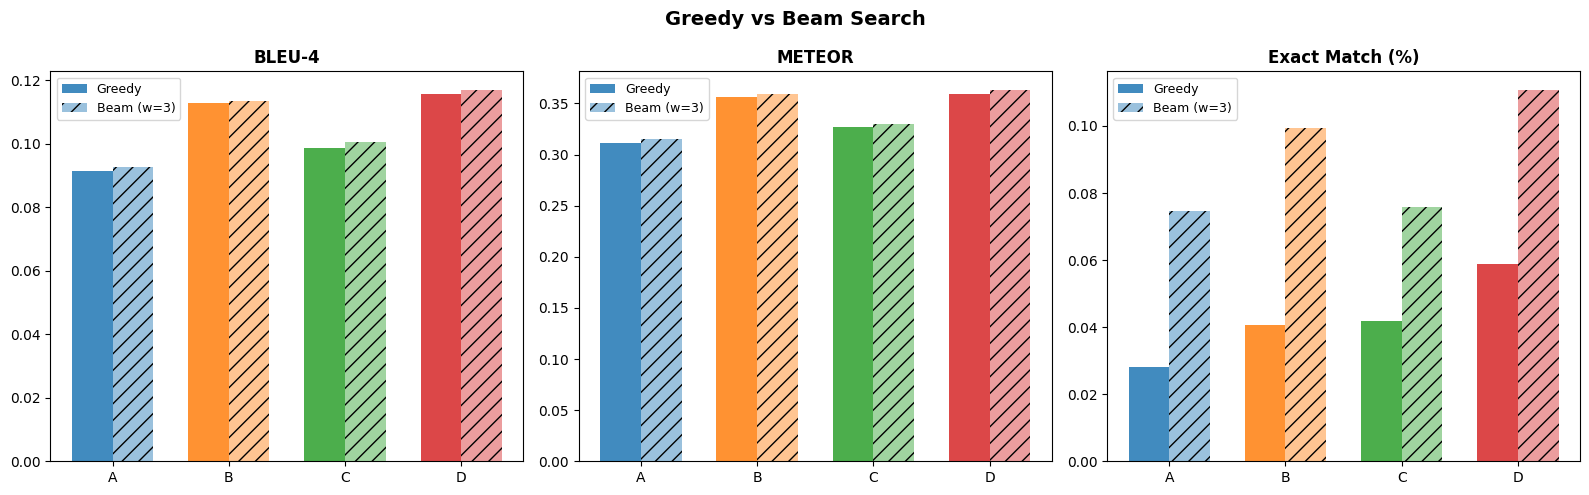

In [29]:
# ── 11. Greedy vs Beam Grouped Bar ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
width = 0.35
x = np.arange(len(models_avail))

for ax, key, label in zip(axes, ['bleu4', 'meteor', 'exact_match'],
                                  ['BLEU-4', 'METEOR', 'Exact Match (%)']):
    gv = [all_metrics_greedy[m].get(key, 0) for m in models_avail]
    bv = [all_metrics_beam.get(m, {}).get(key, 0) for m in models_avail]
    ax.bar(x - width/2, gv, width, label='Greedy',      color=[MODEL_COLORS[m] for m in models_avail], alpha=0.85)
    ax.bar(x + width/2, bv, width, label='Beam (w=3)',  color=[MODEL_COLORS[m] for m in models_avail], alpha=0.45, hatch='//')
    ax.set_xticks(x); ax.set_xticklabels(models_avail)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Greedy vs Beam Search', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/eval_greedy_vs_beam.png', dpi=150, bbox_inches='tight')
plt.show()

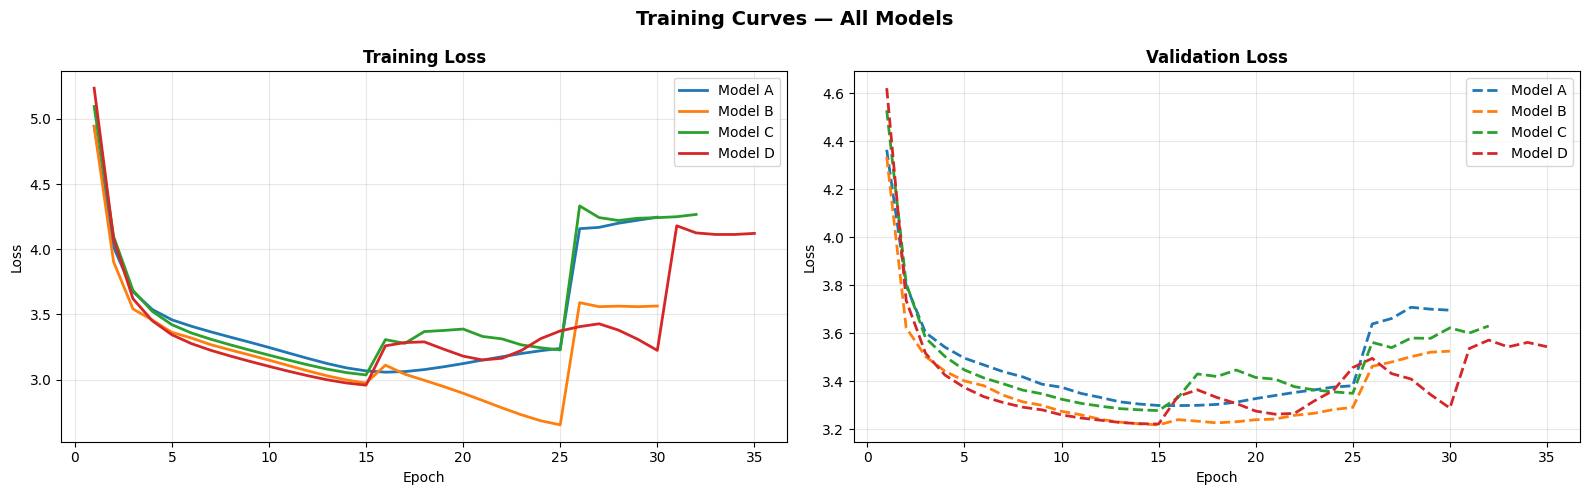

In [30]:
# ── 12. Training Curves ───────────────────────────────────────────────────────
histories = {}
for mt in MODEL_TYPES:
    hist_path = f'{HISTORY_DIR}/history_model_{mt.lower()}.json'
    if os.path.exists(hist_path):
        with open(hist_path) as f:
            histories[mt] = json.load(f)

if histories:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for mt, hist in histories.items():
        color = MODEL_COLORS.get(mt, 'gray')
        epochs = list(range(1, len(hist['train_loss'])+1))
        axes[0].plot(epochs, hist['train_loss'], color=color, label=f'Model {mt}', linewidth=2)
        axes[1].plot(epochs, hist['val_loss'],   color=color, label=f'Model {mt}', linewidth=2,
                     linestyle='--')
    for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title(title, fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No history JSON found.')

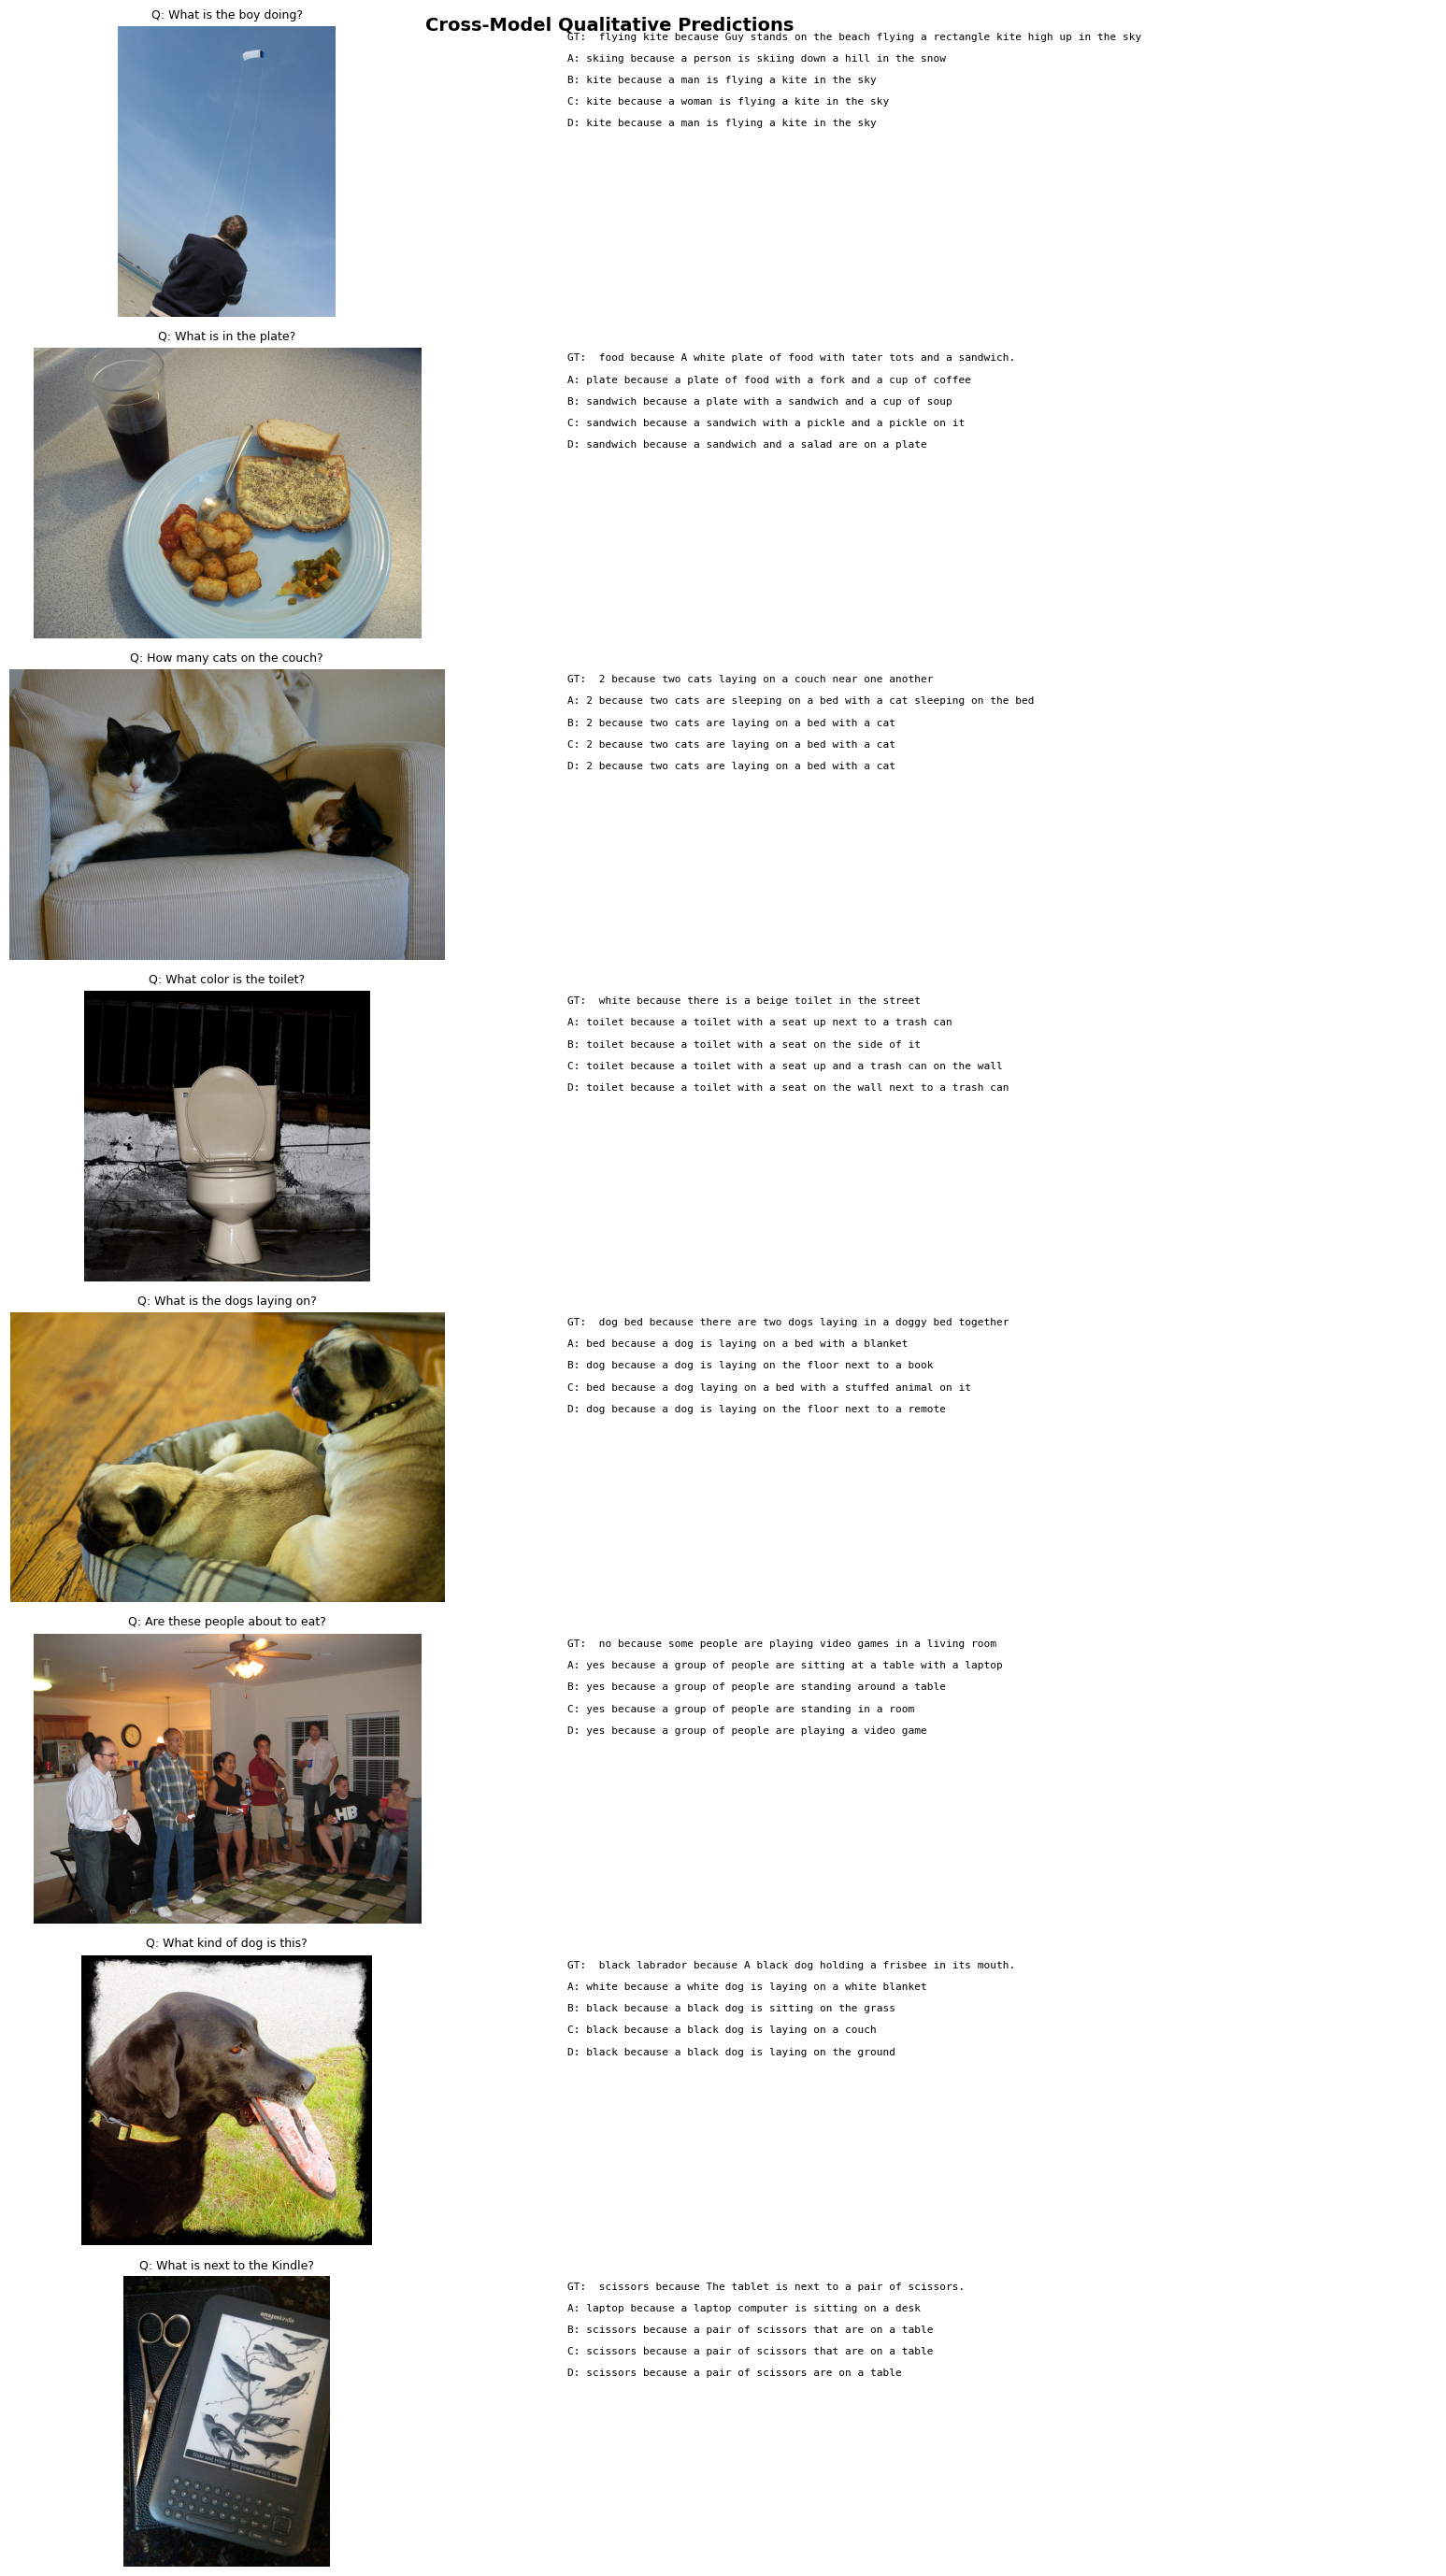

In [31]:
# ── 13. Qualitative: Cross-Model Sample Predictions ──────────────────────────
val_anns = json.load(open(VAL_VQA_E_JSON))
N_SHOW   = 8
random.seed(42)
samples  = random.sample(val_anns, N_SHOW)

from inference import greedy_decode, greedy_decode_with_attention

fig, axes = plt.subplots(N_SHOW, 2, figsize=(18, N_SHOW * 3.5))
for row, ann in enumerate(samples):
    img_id   = ann['img_id']
    question = ann['question']
    gt_ans   = ann['multiple_choice_answer'] + ' because ' + ann['explanation'][0]

    img_file = f'COCO_val2014_{img_id:012d}.jpg'
    img_path = os.path.join(VAL_IMAGE_DIR, img_file)
    if os.path.exists(img_path):
        axes[row, 0].imshow(mpimg.imread(img_path))
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'Q: {question}', fontsize=9)

    pred_lines = [f'GT:  {gt_ans[:110]}']
    sample_idx = next((i for i, a in enumerate(val_dataset.annotations)
                        if a['img_id'] == img_id), None)
    if sample_idx is not None:
        img_t, q_t, _ = val_dataset[sample_idx]
        for mt in MODEL_TYPES:
            if mt not in loaded_models:
                continue
            use_attn = mt in ('C', 'D')
            decode_fn = greedy_decode_with_attention if use_attn else greedy_decode
            pred = decode_fn(loaded_models[mt], img_t, q_t, vocab_a, device=DEVICE)
            pred_lines.append(f'{mt}: {pred[:110]}')

    axes[row, 1].axis('off')
    axes[row, 1].text(0.02, 0.98, '\n\n'.join(pred_lines),
                       transform=axes[row, 1].transAxes, va='top', ha='left',
                       fontsize=8, fontfamily='monospace')

plt.suptitle('Cross-Model Qualitative Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/qualitative_cross_model.png', dpi=120, bbox_inches='tight')
plt.show()


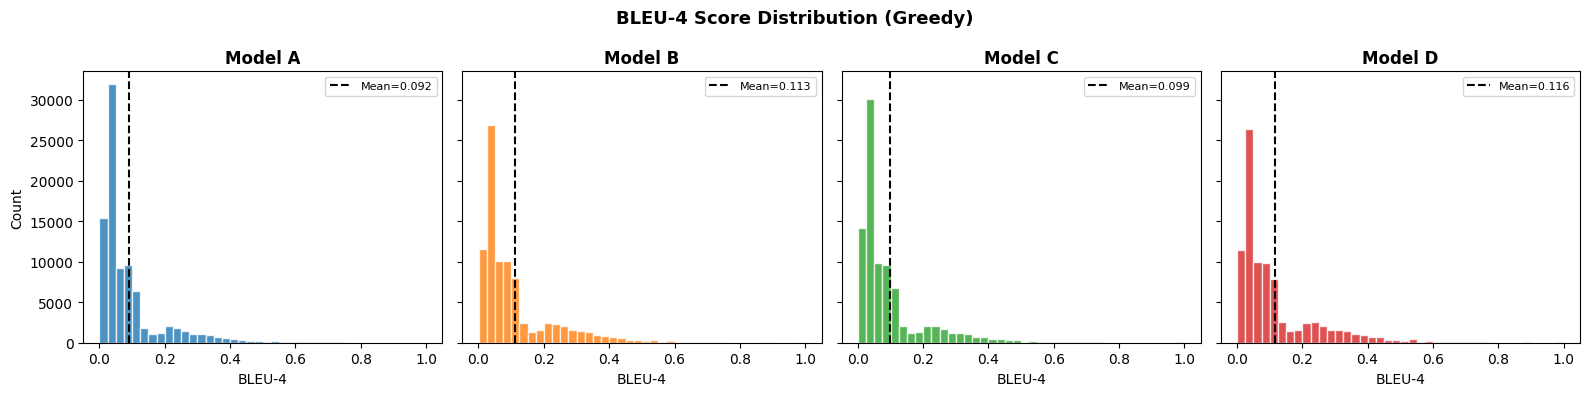

In [32]:
# ── 14. BLEU-4 Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models_avail), figsize=(16, 4), sharey=True)
for ax, mt in zip(axes, models_avail):
    b4_scores = [s['bleu4'] for s in all_per_sample_greedy[mt]]
    ax.hist(b4_scores, bins=40, color=MODEL_COLORS[mt], alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(b4_scores), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={np.mean(b4_scores):.3f}')
    ax.set_title(f'Model {mt}', fontweight='bold')
    ax.set_xlabel('BLEU-4')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('BLEU-4 Score Distribution (Greedy)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/eval_bleu4_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── 15. Top Best & Worst Predictions (Model D) ───────────────────────────────
best_mt = max(models_avail, key=lambda m: all_metrics_greedy[m]['bleu4'])
samples_d = all_per_sample_greedy[best_mt]
sorted_by_bleu = sorted(samples_d, key=lambda x: x['bleu4'], reverse=True)

print(f'=== TOP-10 BEST predictions (Model {best_mt}) ===')
for i, s in enumerate(sorted_by_bleu[:10], 1):
    print(f'{i:2d}. BLEU-4={s["bleu4"]:.3f} | GT: {s["gt"][:80]}')
    print(f'       PRED: {s["pred"][:80]}')

print(f'\n=== TOP-10 WORST predictions (Model {best_mt}) ===')
for i, s in enumerate(sorted_by_bleu[-10:][::-1], 1):
    print(f'{i:2d}. BLEU-4={s["bleu4"]:.4f} | GT: {s["gt"][:80]}')
    print(f'       PRED: {s["pred"][:80]}')

=== TOP-10 BEST predictions (Model D) ===
 1. BLEU-4=1.000 | GT: skateboarding because a man is doing a trick on a skateboard
       PRED: skateboarding because a man is doing a trick on a skateboard
 2. BLEU-4=1.000 | GT: yes because a man in a helmet is riding a motorcycle
       PRED: yes because a man in a helmet is riding a motorcycle
 3. BLEU-4=1.000 | GT: yes because a man is doing a trick on a skateboard
       PRED: yes because a man is doing a trick on a skateboard
 4. BLEU-4=1.000 | GT: skateboarding because a man is doing a trick on a skateboard
       PRED: skateboarding because a man is doing a trick on a skateboard
 5. BLEU-4=1.000 | GT: skateboarding because a man is doing a trick on a skateboard
       PRED: skateboarding because a man is doing a trick on a skateboard
 6. BLEU-4=1.000 | GT: motorcycle because a man riding a motorcycle with a woman on the back
       PRED: motorcycle because a man riding a motorcycle with a woman on the back
 7. BLEU-4=1.000 | GT: cake 

In [34]:
# ── 16. Statistical Significance — Paired t-test ─────────────────────────────
from scipy import stats

print('Paired t-test on per-sample BLEU-4 scores (greedy):')
print(f'{"Pair":<8}  {"t-stat":>8}  {"p-value":>12}  {"significant (α=0.05)":>22}')
print('-' * 60)

pairs = [('A','B'), ('A','C'), ('A','D'), ('B','C'), ('B','D'), ('C','D')]
for m1, m2 in pairs:
    if m1 not in all_per_sample_greedy or m2 not in all_per_sample_greedy:
        continue
    s1 = [s['bleu4'] for s in all_per_sample_greedy[m1]]
    s2 = [s['bleu4'] for s in all_per_sample_greedy[m2]]
    t, p = stats.ttest_rel(s1, s2)
    sig  = '✓ Yes' if p < 0.05 else '✗ No'
    print(f'{m1} vs {m2}  {t:>8.2f}  {p:>12.2e}  {sig:>22}')

Paired t-test on per-sample BLEU-4 scores (greedy):
Pair        t-stat       p-value    significant (α=0.05)
------------------------------------------------------------
A vs B    -61.84      0.00e+00                   ✓ Yes
A vs C    -26.16     2.84e-150                   ✓ Yes
A vs D    -70.35      0.00e+00                   ✓ Yes
B vs C     40.17      0.00e+00                   ✓ Yes
B vs D    -10.59      3.35e-26                   ✓ Yes
C vs D    -49.45      0.00e+00                   ✓ Yes


In [35]:
# ── 17. 95% Bootstrap Confidence Intervals ───────────────────────────────────
def bootstrap_ci(scores, n_boot=1000, ci=0.95):
    scores = np.array(scores)
    boot   = [np.mean(np.random.choice(scores, len(scores), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boot, (1-ci)/2*100)
    hi = np.percentile(boot, (1+ci)/2*100)
    return lo, hi

print('95% Bootstrap CI on BLEU-4 (greedy):')
for mt in models_avail:
    s = [x['bleu4'] for x in all_per_sample_greedy[mt]]
    lo, hi = bootstrap_ci(s)
    mean   = np.mean(s)
    print(f'  Model {mt}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]')

95% Bootstrap CI on BLEU-4 (greedy):
  Model A: 0.0915  [0.0909, 0.0922]
  Model B: 0.1127  [0.1119, 0.1135]
  Model C: 0.0988  [0.0981, 0.0996]
  Model D: 0.1159  [0.1150, 0.1167]


In [36]:
# ── 18. Export Results JSON (includes ROUGE-L) ───────────────────────────────
def clean_for_json(d):
    """Strip per_sample lists (too large) and convert non-serialisable types."""
    out = {}
    for k, v in d.items():
        if k == 'per_sample':
            continue
        out[k] = float(v) if isinstance(v, (np.floating, np.float32, np.float64)) else v
    return out

results_export = {
    'greedy':      {m: clean_for_json(all_metrics_greedy[m])  for m in all_metrics_greedy},
    'beam_search': {m: clean_for_json(all_metrics_beam[m])    for m in all_metrics_beam},
    'config': {
        'num_eval_samples':  NUM_EVAL_SAMPLES,
        'beam_width':        BEAM_WIDTH,
        'no_repeat_ngram':   NO_REPEAT_NGRAM,
        'device':            str(DEVICE),
        'has_rouge':         HAS_ROUGE,
        'has_bertscore':     HAS_BERTSCORE,
    },
    'model_info': {m: {k: (float(v) if isinstance(v, (np.floating, float)) else v)
                        for k, v in info.items()}
                   for m, info in model_info.items()},
}

out_path = f'{OUTPUTS_DIR}/evaluation_results.json'
with open(out_path, 'w') as f:
    json.dump(results_export, f, indent=2)
print(f'✓ Results saved → {out_path}')

# Quick summary printout
print('\n' + '='*70)
print('FINAL SUMMARY — GREEDY DECODING')
print('='*70)
hdr = f'{"Model":<8} {"BLEU-4":>8} {"METEOR":>8} {"ROUGE-L":>9} {"BERTSc":>8} {"EM":>7}'
print(hdr)
print('-' * len(hdr))
for mt in sorted(all_metrics_greedy):
    r = all_metrics_greedy[mt]
    rl = f"{r['rougeL']:.4f}" if r.get('rougeL') is not None else '  N/A '
    bs = f"{r['bertscore']:.4f}" if r.get('bertscore') else '  N/A '
    print(f"Model {mt:<3} {r['bleu4']:>8.4f} {r['meteor']:>8.4f} {rl:>9} {bs:>8} {r['exact_match']:>6.2f}%")

✓ Results saved → outputs/evaluation_results.json

FINAL SUMMARY — GREEDY DECODING
Model      BLEU-4   METEOR   ROUGE-L   BERTSc      EM
-----------------------------------------------------
Model A     0.0915   0.3117    0.3828   0.9008   0.03%
Model B     0.1127   0.3561    0.4237   0.9081   0.04%
Model C     0.0988   0.3271    0.3971   0.9034   0.04%
Model D     0.1159   0.3595    0.4270   0.9085   0.06%


---
## Done!

Results saved to `outputs/evaluation_results.json`. Update REPORT.md §15.4/15.5 and §16.9.2 with the ROUGE-L values.